In [1]:
import os
import numpy as np
import math
from time import time
from PIL import Image
import cv2
from matplotlib import pyplot as plt
import csv

In [2]:
glioma_image_numbers = []
glioma_save_image_numbers = []

path, dirs, files = next(os.walk("/Users/vladkorsikov/research/dataset_main/3_glioma_centered"))
glioma_count = len(files)-1

path, dirs, files = next(os.walk("/Users/vladkorsikov/research/dataset_main/3_meningioma_centered"))
meningioma_count = len(files)-1

path, dirs, files = next(os.walk("/Users/vladkorsikov/research/dataset_main/3_pituitary_centered"))
pituitary_count = len(files)-1

path, dirs, files = next(os.walk("/Users/vladkorsikov/research/dataset_main/3_test_centered"))
test_count = len(files)-1

glioma_image_numbers = []
glioma_save_image_numbers = []
meningioma_image_numbers = []
meningioma_save_image_numbers = []
pituitary_image_numbers = []
pituitary_save_image_numbers = []
test_image_numbers = []
test_save_image_numbers = []

#Местонахождение папок
path_glioma = '/Users/vladkorsikov/research/dataset_main/3_glioma_centered'
path_meningioma = '/Users/vladkorsikov/research/dataset_main/3_meningioma_centered'
path_pituitary = '/Users/vladkorsikov/research/dataset_main/3_pituitary_centered'
path_test = '/Users/vladkorsikov/research/dataset_main/3_test_centered'

#заполняем списки имен
count = 0
for i in range(glioma_count):
  count += 1
  image_name = f'{path_glioma}/glioma{str(count)}.png'
  glioma_image_numbers.append(image_name)



count = 0
for i in range(meningioma_count):
  count += 1
  image_name = f'{path_meningioma}/meningioma{str(count)}.png'
  meningioma_image_numbers.append(image_name)


count = 0
for i in range(pituitary_count):
  count += 1
  image_name = f'{path_pituitary}/pituitary{str(count)}.png'
  pituitary_image_numbers.append(image_name)


count = 0
for i in range(test_count):
  count += 1
  image_name = f'{path_test}/test{str(count)}.png'
  test_image_numbers.append(image_name)

print(len(glioma_image_numbers))
print(len(meningioma_image_numbers))
print(len(pituitary_image_numbers))
print(len(test_image_numbers))
print(glioma_image_numbers[-1])
print(meningioma_image_numbers[-1])
print(pituitary_image_numbers[-1])
print(test_image_numbers[-1])



100
100
100
75
/Users/vladkorsikov/research/dataset_main/3_glioma_centered/glioma100.png
/Users/vladkorsikov/research/dataset_main/3_meningioma_centered/meningioma100.png
/Users/vladkorsikov/research/dataset_main/3_pituitary_centered/pituitary100.png
/Users/vladkorsikov/research/dataset_main/3_test_centered/test75.png


In [3]:
#Берём тестовое изображение, чтобы получить его полезные признаки
road_1 = glioma_image_numbers[17]

img_brain = cv2.imread(road_1) #, cv2.IMREAD_GRAYSCALE)
img_brain_grey = cv2.imread(road_1, cv2.IMREAD_GRAYSCALE)


image_length = len(img_brain_grey)
image_width = len(img_brain_grey[0])

#Задаём функцию нормализации, возвращает набор строк, из которых состоит ЦВЕТНОЕ изображение
def normalization_colour(img_brain_grey, img_brain, image_width):
  image_list_2 = []
  image_list_3 = []
  for line, line_2 in zip(img_brain_grey, img_brain):
    list_for_image = []
    list_for_image_2 = []
    for pixel_number in range(image_width):
      a = line[pixel_number]
      b = line_2[pixel_number]
      if a<10:
        a=0
        b=[0, 0, 0]
      else:
        a=a
        b=b
      list_for_image.append(a)
      list_for_image_2.append(b)
    image_list_2.append(list_for_image)
    image_list_3.append(list_for_image_2)
  return image_list_3

#Задаём функцию нормализации, возвращает набор строк, из которых состоит СЕРОЕ изображение
def normalization_grey(img_brain_grey, img_brain, image_width):
  image_list_2 = []
  image_list_3 = []
  for line, line_2 in zip(img_brain_grey, img_brain):
    list_for_image = []
    list_for_image_2 = []
    for pixel_number in range(image_width):
      a = line[pixel_number]
      b = line_2[pixel_number]
      if a<10:
        a=0
        b=[0, 0, 0]
      else:
        a=a
        b=b
      list_for_image.append(a)
      list_for_image_2.append(b)
    image_list_2.append(list_for_image)
    image_list_3.append(list_for_image_2)
  return image_list_2

test_1 =  normalization_colour(img_brain_grey, img_brain, image_width)
test_2 = normalization_grey(img_brain_grey, img_brain, image_width)

test_1_1 = np.array(test_1)
test_2_1 = np.array(test_2)

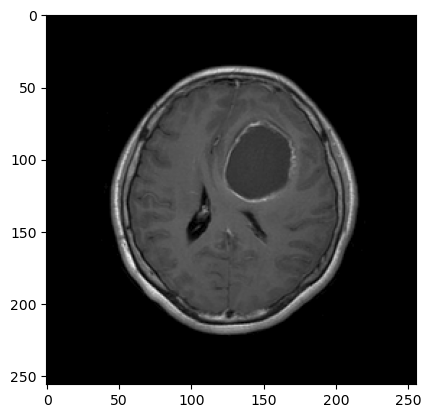

In [4]:
plt.imshow (test_1_1)

#Тут преобразуем черно-белое изображение в вектор признаков

In [6]:
image_length = len(img_brain_grey)
image_width = len(img_brain_grey[0])

def vectorization_horizontal(img_brain_grey):
    vector_hor = []
    for line in img_brain_grey:
        for pixel in line:
            vector_hor.append(pixel)
    return vector_hor

def vectorization_verical(img_brain_grey):
    vector_ver = []
    for pixel in range(image_width):
        for line in img_brain_grey:
            vector_ver.append(line[pixel])
    return vector_ver

horizontal = vectorization_horizontal(img_brain_grey)
vertical = vectorization_verical(img_brain_grey)
print(len(horizontal))
print(len(vertical))

65536
65536


In [7]:
glioma_hor_vectors = []
glioma_ver_vectors = []
meningioma_hor_vectors = []
meningioma_ver_vectors = []
pituitary_hor_vectors = []
pituitary_ver_vectors = []
test_hor_vectors = []
test_ver_vectors = []

for road_2 in glioma_image_numbers:
    img_brain_2 = cv2.imread(road_2)
    img_brain_grey_2 = cv2.imread(road_2, cv2.IMREAD_GRAYSCALE)
    horizontal = vectorization_horizontal(img_brain_grey_2)
    vertical = vectorization_verical(img_brain_grey_2)
    glioma_hor_vectors.append(horizontal)
    glioma_ver_vectors.append(vertical)
print('glioma done')

for road_2 in meningioma_image_numbers:
    img_brain_2 = cv2.imread(road_2)
    img_brain_grey_2 = cv2.imread(road_2, cv2.IMREAD_GRAYSCALE)
    horizontal = vectorization_horizontal(img_brain_grey_2)
    vertical = vectorization_verical(img_brain_grey_2)
    meningioma_hor_vectors.append(horizontal)
    meningioma_ver_vectors.append(vertical)
print('meningioma done')

for road_2 in pituitary_image_numbers:
    img_brain_2 = cv2.imread(road_2)
    img_brain_grey_2 = cv2.imread(road_2, cv2.IMREAD_GRAYSCALE)
    horizontal = vectorization_horizontal(img_brain_grey_2)
    vertical = vectorization_verical(img_brain_grey_2)
    pituitary_hor_vectors.append(horizontal)
    pituitary_ver_vectors.append(vertical)
print('pituitary done')

for road_2 in test_image_numbers:
    img_brain_2 = cv2.imread(road_2)
    img_brain_grey_2 = cv2.imread(road_2, cv2.IMREAD_GRAYSCALE)
    horizontal = vectorization_horizontal(img_brain_grey_2)
    vertical = vectorization_verical(img_brain_grey_2)
    test_hor_vectors.append(horizontal)
    test_ver_vectors.append(vertical)
print('test done')

print(len(glioma_hor_vectors))
print(len(glioma_hor_vectors[1]))
print(len(glioma_ver_vectors))
print(len(glioma_ver_vectors[1]))
print(len(meningioma_hor_vectors))
print(len(meningioma_hor_vectors[1]))
print(len(meningioma_ver_vectors))
print(len(meningioma_ver_vectors[1]))
print(len(pituitary_hor_vectors))
print(len(pituitary_hor_vectors[1]))
print(len(pituitary_ver_vectors))
print(len(pituitary_ver_vectors[1]))
print(len(test_hor_vectors))
print(len(test_hor_vectors[1]))
print(len(test_ver_vectors))
print(len(test_ver_vectors[1]))

with open('/Users/vladkorsikov/research/dataset_main/5_all_vectors/glioma/glioma_horizontal_vector.csv', 'w', newline='') as f:
    csv.writer(f).writerows(glioma_hor_vectors)
with open('/Users/vladkorsikov/research/dataset_main/5_all_vectors/glioma/glioma_vertical_vector.csv', 'w', newline='') as f:
    csv.writer(f).writerows(glioma_hor_vectors)

with open('/Users/vladkorsikov/research/dataset_main/5_all_vectors/meningioma/meningioma_horizontal_vector.csv', 'w', newline='') as f:
    csv.writer(f).writerows(meningioma_hor_vectors)
with open('/Users/vladkorsikov/research/dataset_main/5_all_vectors/meningioma/meningioma_vertical_vector.csv', 'w', newline='') as f:
    csv.writer(f).writerows(meningioma_ver_vectors)

with open('/Users/vladkorsikov/research/dataset_main/5_all_vectors/pituitary/pituitary_horizontal_vector.csv', 'w', newline='') as f:
    csv.writer(f).writerows(pituitary_hor_vectors)
with open('/Users/vladkorsikov/research/dataset_main/5_all_vectors/pituitary/pituitary_vertical_vector.csv', 'w', newline='') as f:
    csv.writer(f).writerows(pituitary_ver_vectors)

with open('/Users/vladkorsikov/research/dataset_main/5_all_vectors/test/test_horizontal_vector.csv', 'w', newline='') as f:
    csv.writer(f).writerows(test_hor_vectors)
with open('/Users/vladkorsikov/research/dataset_main/5_all_vectors/test/test_vertical_vector.csv', 'w', newline='') as f:
    csv.writer(f).writerows(test_hor_vectors)

glioma done
meningioma done
pituitary done
test done
100
65536
100
65536
100
65536
100
65536
100
65536
100
65536
75
65536
75
65536


In [8]:
#import csv
#glioma_hor_vectors = [[46, 54], [24, 64], [42, 76]]
#f = open('/Users/vladkorsikov/research/dataset_main/5_all_vectors/glioma_horizontal_vector.txt', 'w')
#f.write(glioma_hor_vectors)
#f.close()

#with open('/Users/vladkorsikov/research/dataset_main/5_all_vectors/glioma_horizontal_vector.csv', 'w', newline='') as f:
#    csv.writer(f).writerows(glioma_hor_vectors)

#with open('/Users/vladkorsikov/research/dataset_main/5_all_vectors/glioma_horizontal_vector.csv', newline='') as file:
#    glioma_hor_vectors_2 = [row for row in csv.reader(file)]

#print(glioma_hor_vectors_2)

#lol = glioma_hor_vectors_2[1]
#meme = int(lol[1])

#print(meme)